# EViT-UNet: Efficient Vision Transformer U-Net

Implementation of EViT-UNet for nuclei segmentation on the **TNBC** dataset.  
Paper repo: [Retinal-Research/EVIT-UNET](https://github.com/Retinal-Research/EVIT-UNET)


In [1]:
import os
import copy
import math
import itertools
from typing import Dict

import numpy as np
import cv2
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader
import random
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from timm.models.layers import DropPath, trunc_normal_, to_2tuple

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [2]:
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(seed=42)
print("Random seed initialized to 42.")

Random seed initialized to 42.


## EViT-UNet Architecture


In [3]:
expansion_ratios_L = {
    '0': [4, 4, 4, 4, 4],
    '1': [4, 4, 4, 4, 4],
    '2': [4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4],
    '3': [4, 4, 4, 3, 3, 3, 3, 4, 4, 4],
}

expansion_ratios_L_reverse = {
    '3': [4, 4, 4, 4, 4],
    '2': [4, 4, 4, 4, 4],
    '1': [4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4],
    '0': [4, 4, 4, 3, 3, 3, 3, 4, 4, 4],
}

class Attention4D(torch.nn.Module):
    def __init__(self, dim=384, key_dim=32, num_heads=8,
                 attn_ratio=4,
                 resolution=7,
                 act_layer=nn.ReLU,
                 stride=None):
        super().__init__()
        self.num_heads = num_heads
        self.scale = key_dim ** -0.5
        self.key_dim = key_dim
        self.nh_kd = nh_kd = key_dim * num_heads

        if stride is not None:
            self.resolution = math.ceil(resolution / stride)
            self.stride_conv = nn.Sequential(nn.Conv2d(dim, dim, kernel_size=3, stride=stride, padding=1, groups=dim),
                                             nn.BatchNorm2d(dim), )
            self.upsample = nn.Upsample(scale_factor=stride, mode='bilinear')
        else:
            self.resolution = resolution
            self.stride_conv = None
            self.upsample = None

        self.N = self.resolution ** 2
        self.N2 = self.N
        self.d = int(attn_ratio * key_dim)
        self.dh = int(attn_ratio * key_dim) * num_heads
        self.attn_ratio = attn_ratio
        h = self.dh + nh_kd * 2
        self.q = nn.Sequential(nn.Conv2d(dim, self.num_heads * self.key_dim, 1),
                               nn.BatchNorm2d(self.num_heads * self.key_dim), )
        self.k = nn.Sequential(nn.Conv2d(dim, self.num_heads * self.key_dim, 1),
                               nn.BatchNorm2d(self.num_heads * self.key_dim), )
        self.v = nn.Sequential(nn.Conv2d(dim, self.num_heads * self.d, 1),
                               nn.BatchNorm2d(self.num_heads * self.d),
                               )
        self.v_local = nn.Sequential(nn.Conv2d(self.num_heads * self.d, self.num_heads * self.d,
                                               kernel_size=3, stride=1, padding=1, groups=self.num_heads * self.d),
                                     nn.BatchNorm2d(self.num_heads * self.d), )
        self.talking_head1 = nn.Conv2d(self.num_heads, self.num_heads, kernel_size=1, stride=1, padding=0)
        self.talking_head2 = nn.Conv2d(self.num_heads, self.num_heads, kernel_size=1, stride=1, padding=0)

        self.proj = nn.Sequential(act_layer(),
                                  nn.Conv2d(self.dh, dim, 1),
                                  nn.BatchNorm2d(dim), )

        points = list(itertools.product(range(self.resolution), range(self.resolution)))
        N = len(points)
        attention_offsets = {}
        idxs = []
        for p1 in points:
            for p2 in points:
                offset = (abs(p1[0] - p2[0]), abs(p1[1] - p2[1]))
                if offset not in attention_offsets:
                    attention_offsets[offset] = len(attention_offsets)
                idxs.append(attention_offsets[offset])
        self.attention_biases = torch.nn.Parameter(
            torch.zeros(num_heads, len(attention_offsets)))
        self.register_buffer('attention_bias_idxs',
                             torch.LongTensor(idxs).view(N, N))

    @torch.no_grad()
    def train(self, mode=True):
        super().train(mode)
        if mode and hasattr(self, 'ab'):
            del self.ab
        else:
            self.ab = self.attention_biases[:, self.attention_bias_idxs]

    def forward(self, x):  # x (B,N,C)
        B, C, H, W = x.shape
        if self.stride_conv is not None:
            x = self.stride_conv(x)

        q = self.q(x).flatten(2).reshape(B, self.num_heads, -1, self.N).permute(0, 1, 3, 2)
        k = self.k(x).flatten(2).reshape(B, self.num_heads, -1, self.N).permute(0, 1, 2, 3)
        v = self.v(x)
        v_local = self.v_local(v)
        v = v.flatten(2).reshape(B, self.num_heads, -1, self.N).permute(0, 1, 3, 2)

        attn = (
                (q @ k) * self.scale
                +
                (self.attention_biases[:, self.attention_bias_idxs]
                 if self.training else self.ab)
        )
        attn = self.talking_head1(attn)
        attn = attn.softmax(dim=-1)
        attn = self.talking_head2(attn)

        x = (attn @ v)

        out = x.transpose(2, 3).reshape(B, self.dh, self.resolution, self.resolution) + v_local
        if self.upsample is not None:
            out = self.upsample(out)

        out = self.proj(out)
        return out


def stem(in_chs, out_chs, act_layer=nn.ReLU):
    return nn.Sequential(
        nn.Conv2d(in_chs, out_chs // 2, kernel_size=3, stride=2, padding=1),
        nn.BatchNorm2d(out_chs // 2),
        act_layer(),
        nn.Conv2d(out_chs // 2, out_chs, kernel_size=3, stride=2, padding=1),
        nn.BatchNorm2d(out_chs),
        act_layer(),
    )
def merge(in_chs, out_chs, act_layer=nn.ReLU):
    return nn.Sequential(
        nn.ConvTranspose2d(in_chs, out_chs // 2, kernel_size=3, stride=2, padding=1, output_padding=1),
        nn.BatchNorm2d(out_chs // 2),
        act_layer(),
        nn.ConvTranspose2d(out_chs // 2, out_chs, kernel_size=3, stride=2, padding=1, output_padding=1),
        nn.BatchNorm2d(out_chs),
        act_layer(),
    )

class LGQuery(torch.nn.Module):
    def __init__(self, in_dim, out_dim, resolution1, resolution2):
        super().__init__()
        self.resolution1 = resolution1
        self.resolution2 = resolution2
        self.pool = nn.AvgPool2d(1, 2, 0)
        self.local = nn.Sequential(nn.Conv2d(in_dim, in_dim, kernel_size=3, stride=2, padding=1, groups=in_dim),
                                   )
        self.proj = nn.Sequential(nn.Conv2d(in_dim, out_dim, 1),
                                  nn.BatchNorm2d(out_dim), )

    def forward(self, x):
        local_q = self.local(x)
        pool_q = self.pool(x)
        q = local_q + pool_q
        q = self.proj(q)
        return q
    
class UpLGQuery(torch.nn.Module):
    def __init__(self, in_dim, out_dim, resolution1, resolution2):
        super().__init__()
        self.resolution1 = resolution1
        self.resolution2 = resolution2
        self.pool = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)  
        self.local = nn.Sequential(
            nn.ConvTranspose2d(in_dim, in_dim, kernel_size=3, stride=2, padding=1, output_padding=1, groups=in_dim),
        )
        self.proj = nn.Sequential(
            nn.Conv2d(in_dim, out_dim, 1),
            nn.BatchNorm2d(out_dim),
        )

    def forward(self, x):
        local_q = self.local(x)
        pool_q = self.pool(x)
        q = local_q + pool_q
        q = self.proj(q)
        return q


class Attention4DDownsample(torch.nn.Module):
    def __init__(self, dim=384, key_dim=16, num_heads=8,
                 attn_ratio=4,
                 resolution=7,
                 out_dim=None,
                 act_layer=None,
                 ):
        super().__init__()

        self.num_heads = num_heads
        self.scale = key_dim ** -0.5
        self.key_dim = key_dim
        self.nh_kd = nh_kd = key_dim * num_heads

        self.resolution = resolution

        self.d = int(attn_ratio * key_dim)
        self.dh = int(attn_ratio * key_dim) * num_heads
        self.attn_ratio = attn_ratio
        h = self.dh + nh_kd * 2

        if out_dim is not None:
            self.out_dim = out_dim
        else:
            self.out_dim = dim
        self.resolution2 = math.ceil(self.resolution / 2)
        self.q = LGQuery(dim, self.num_heads * self.key_dim, self.resolution, self.resolution2)

        self.N = self.resolution ** 2
        self.N2 = self.resolution2 ** 2

        self.k = nn.Sequential(nn.Conv2d(dim, self.num_heads * self.key_dim, 1),
                               nn.BatchNorm2d(self.num_heads * self.key_dim), )
        self.v = nn.Sequential(nn.Conv2d(dim, self.num_heads * self.d, 1),
                               nn.BatchNorm2d(self.num_heads * self.d),
                               )
        self.v_local = nn.Sequential(nn.Conv2d(self.num_heads * self.d, self.num_heads * self.d,
                                               kernel_size=3, stride=2, padding=1, groups=self.num_heads * self.d),
                                     nn.BatchNorm2d(self.num_heads * self.d), )

        self.proj = nn.Sequential(
            act_layer(),
            nn.Conv2d(self.dh, self.out_dim, 1),
            nn.BatchNorm2d(self.out_dim), )

        points = list(itertools.product(range(self.resolution), range(self.resolution)))
        points_ = list(itertools.product(
            range(self.resolution2), range(self.resolution2)))
        N = len(points)
        N_ = len(points_)
        attention_offsets = {}
        idxs = []
        for p1 in points_:
            for p2 in points:
                size = 1
                offset = (
                    abs(p1[0] * math.ceil(self.resolution / self.resolution2) - p2[0] + (size - 1) / 2),
                    abs(p1[1] * math.ceil(self.resolution / self.resolution2) - p2[1] + (size - 1) / 2))
                if offset not in attention_offsets:
                    attention_offsets[offset] = len(attention_offsets)
                idxs.append(attention_offsets[offset])
        self.attention_biases = torch.nn.Parameter(
            torch.zeros(num_heads, len(attention_offsets)))
        self.register_buffer('attention_bias_idxs',
                             torch.LongTensor(idxs).view(N_, N))

    @torch.no_grad()
    def train(self, mode=True):
        super().train(mode)
        if mode and hasattr(self, 'ab'):
            del self.ab
        else:
            self.ab = self.attention_biases[:, self.attention_bias_idxs]

    def forward(self, x):  # x (B,N,C)
        B, C, H, W = x.shape

        q = self.q(x).flatten(2).reshape(B, self.num_heads, -1, self.N2).permute(0, 1, 3, 2)
        k = self.k(x).flatten(2).reshape(B, self.num_heads, -1, self.N).permute(0, 1, 2, 3)
        v = self.v(x)
        v_local = self.v_local(v)
        v = v.flatten(2).reshape(B, self.num_heads, -1, self.N).permute(0, 1, 3, 2)

        attn = (
                (q @ k) * self.scale
                +
                (self.attention_biases[:, self.attention_bias_idxs]
                 if self.training else self.ab)
        )
        attn = attn.softmax(dim=-1)
        x = (attn @ v).transpose(2, 3)
        out = x.reshape(B, self.dh, self.resolution2, self.resolution2) + v_local

        out = self.proj(out)
        return out

class Attention4DUpsample(nn.Module):
    def __init__(self, dim=384, key_dim=16, num_heads=8,
                 attn_ratio=4,
                 resolution=7,
                 resolution2=7,
                 out_dim=None,
                 act_layer=None,
                 ):
        super().__init__()

        self.num_heads = num_heads
        self.scale = key_dim ** -0.5
        self.key_dim = key_dim
        self.nh_kd = nh_kd = key_dim * num_heads

        self.resolution = resolution

        self.d = int(attn_ratio * key_dim)
        self.dh = int(attn_ratio * key_dim) * num_heads
        self.attn_ratio = attn_ratio
        h = self.dh + nh_kd * 2

        if out_dim is not None:
            self.out_dim = out_dim
        else:
            self.out_dim = dim
        self.resolution2 = resolution2  
        self.q = UpLGQuery(dim, self.num_heads * self.key_dim, self.resolution, self.resolution2)

        self.N = self.resolution ** 2
        self.N2 = self.resolution2 ** 2

        self.k = nn.Sequential(nn.Conv2d(dim, self.num_heads * self.key_dim, 1),
                               nn.BatchNorm2d(self.num_heads * self.key_dim), )
        self.v = nn.Sequential(nn.Conv2d(dim, self.num_heads * self.d, 1),
                               nn.BatchNorm2d(self.num_heads * self.d),
                               )
        self.v_local = nn.Sequential(nn.ConvTranspose2d(self.num_heads * self.d, self.num_heads * self.d,
                                               kernel_size=3, stride=2, padding=1, output_padding=1, groups=self.num_heads * self.d),
                                     nn.BatchNorm2d(self.num_heads * self.d), )

        self.proj = nn.Sequential(
            act_layer(),
            nn.Conv2d(self.dh, self.out_dim, 1),
            nn.BatchNorm2d(self.out_dim), )

        points = list(itertools.product(range(self.resolution), range(self.resolution)))
        points_ = list(itertools.product(
            range(self.resolution2), range(self.resolution2)))
        N = len(points)
        N_ = len(points_)
        attention_offsets = {}
        idxs = []

    def forward(self, x):  # x (B,N,C)
        B, C, H, W = x.shape

        q = self.q(x).flatten(2).reshape(B, self.num_heads, -1, self.N2).permute(0, 1, 3, 2)
        k = self.k(x).flatten(2).reshape(B, self.num_heads, -1, self.N).permute(0, 1, 2, 3)
        v = self.v(x)
        v_local = self.v_local(v)
        v = v.flatten(2).reshape(B, self.num_heads, -1, self.N).permute(0, 1, 3, 2)
        

        attn = (
                (q @ k) * self.scale
        )

        attn = attn.softmax(dim=-1)
        x = (attn @ v).transpose(2, 3)
        out = x.reshape(B, self.dh, self.resolution2, self.resolution2) + v_local

        out = self.proj(out)
        return out
    
    
class Embedding(nn.Module):
    def __init__(self, patch_size=3, stride=2, padding=1,
                 in_chans=3, embed_dim=768, norm_layer=nn.BatchNorm2d,
                 light=False, asub=False, resolution=None, act_layer=nn.ReLU, attn_block=Attention4DDownsample):
        super().__init__()
        self.light = light
        self.asub = asub

        if self.light:
            self.new_proj = nn.Sequential(
                nn.Conv2d(in_chans, in_chans, kernel_size=3, stride=2, padding=1, groups=in_chans),
                nn.BatchNorm2d(in_chans),
                nn.Hardswish(),
                nn.Conv2d(in_chans, embed_dim, kernel_size=1, stride=1, padding=0),
                nn.BatchNorm2d(embed_dim),
            )
            self.skip = nn.Sequential(
                nn.Conv2d(in_chans, embed_dim, kernel_size=1, stride=2, padding=0),
                nn.BatchNorm2d(embed_dim)
            )
        elif self.asub:
            self.attn = attn_block(dim=in_chans, out_dim=embed_dim,
                                   resolution=resolution, act_layer=act_layer)
            patch_size = to_2tuple(patch_size)
            stride = to_2tuple(stride)
            padding = to_2tuple(padding)
            self.conv = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size,
                                  stride=stride, padding=padding)
            self.bn = norm_layer(embed_dim) if norm_layer else nn.Identity()
        else:
            patch_size = to_2tuple(patch_size)
            stride = to_2tuple(stride)
            padding = to_2tuple(padding)
            self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size,
                                  stride=stride, padding=padding)
            self.norm = norm_layer(embed_dim) if norm_layer else nn.Identity()

    def forward(self, x):
        if self.light:
            out = self.new_proj(x) + self.skip(x)
        elif self.asub:
            out_conv = self.conv(x)
            out_conv = self.bn(out_conv)
            out = self.attn(x) + out_conv
        else:
            x = self.proj(x)
            out = self.norm(x)
        return out

class Expanding(nn.Module):
    def __init__(self, patch_size=2, stride=2, padding=1,
                 in_chans=3, embed_dim=768, norm_layer=nn.BatchNorm2d,
                 light=False, asub=False, resolution=None, resolution2=None, act_layer=nn.ReLU,
                 attn_block=Attention4DUpsample):  
        super().__init__()
        self.light = light
        self.asub = asub
        
        if self.light:
            self.new_proj = nn.Sequential(
                nn.ConvTranspose2d(in_chans, in_chans, kernel_size=3, stride=2, padding=1, output_padding=1, groups=in_chans),
                nn.BatchNorm2d(in_chans),
                nn.Hardswish(),
                nn.Conv2d(in_chans, embed_dim, kernel_size=1, stride=1, padding=0),
                nn.BatchNorm2d(embed_dim),
            )
            self.skip = nn.Sequential(
                nn.ConvTranspose2d(in_chans, embed_dim, kernel_size=3, stride=2, padding=1, output_padding=1),
                nn.BatchNorm2d(embed_dim),
            )
        elif self.asub:
            self.attn = attn_block(dim=in_chans, out_dim=embed_dim,
                                   resolution=resolution, resolution2=resolution2, act_layer=act_layer)
            patch_size = (patch_size, patch_size)
            stride = (stride, stride)
            padding = (padding, padding)
            self.conv = nn.ConvTranspose2d(in_chans, embed_dim, kernel_size=patch_size, stride=stride, padding=padding, output_padding=1)
            self.bn = norm_layer(embed_dim) if norm_layer else nn.Identity()
        else:
            patch_size = (patch_size, patch_size)
            stride = (stride, stride)
            padding = (padding, padding)
            self.proj = nn.ConvTranspose2d(in_chans, embed_dim, kernel_size=patch_size, stride=stride, padding=padding, output_padding=1)
            self.norm = norm_layer(embed_dim) if norm_layer else nn.Identity()
    
    def forward(self, x):
        if self.light:
            out = self.new_proj(x) + self.skip(x)
        elif self.asub:
            out_conv = self.conv(x)
            out_conv = self.bn(out_conv)
            
            out = self.attn(x) + out_conv
        else:
            x = self.proj(x)
            out = self.norm(x)

        return out
    
    
class Mlp(nn.Module):
    """
    Implementation of MLP with 1*1 convolutions.
    Input: tensor with shape [B, C, H, W]
    """

    def __init__(self, in_features, hidden_features=None,
                 out_features=None, act_layer=nn.GELU, drop=0., mid_conv=False):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.mid_conv = mid_conv
        self.fc1 = nn.Conv2d(in_features, hidden_features, 1)
        self.act = act_layer()
        self.fc2 = nn.Conv2d(hidden_features, out_features, 1)
        self.drop = nn.Dropout(drop)
        self.apply(self._init_weights)

        if self.mid_conv:
            self.mid = nn.Conv2d(hidden_features, hidden_features, kernel_size=3, stride=1, padding=1,
                                 groups=hidden_features)
            self.mid_norm = nn.BatchNorm2d(hidden_features)

        self.norm1 = nn.BatchNorm2d(hidden_features)
        self.norm2 = nn.BatchNorm2d(out_features)

    def _init_weights(self, m):
        if isinstance(m, nn.Conv2d):
            trunc_normal_(m.weight, std=.02)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.fc1(x)
        x = self.norm1(x)
        x = self.act(x)

        if self.mid_conv:
            x_mid = self.mid(x)
            x_mid = self.mid_norm(x_mid)
            x = self.act(x_mid)
        x = self.drop(x)

        x = self.fc2(x)
        x = self.norm2(x)

        x = self.drop(x)
        return x


class AttnFFN(nn.Module):
    def __init__(self, dim, mlp_ratio=4.,
                 act_layer=nn.ReLU, norm_layer=nn.LayerNorm,
                 drop=0., drop_path=0.,
                 use_layer_scale=True, layer_scale_init_value=1e-5,
                 resolution=7, stride=None):

        super().__init__()

        self.token_mixer = Attention4D(dim, resolution=resolution, act_layer=act_layer, stride=stride)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = Mlp(in_features=dim, hidden_features=mlp_hidden_dim,
                       act_layer=act_layer, drop=drop, mid_conv=True)

        self.drop_path = DropPath(drop_path) if drop_path > 0. \
            else nn.Identity()
        self.use_layer_scale = use_layer_scale
        if use_layer_scale:
            self.layer_scale_1 = nn.Parameter(
                layer_scale_init_value * torch.ones(dim).unsqueeze(-1).unsqueeze(-1), requires_grad=True)
            self.layer_scale_2 = nn.Parameter(
                layer_scale_init_value * torch.ones(dim).unsqueeze(-1).unsqueeze(-1), requires_grad=True)

    def forward(self, x):
        if self.use_layer_scale:
            x = x + self.drop_path(self.layer_scale_1 * self.token_mixer(x))
            x = x + self.drop_path(self.layer_scale_2 * self.mlp(x))

        else:
            x = x + self.drop_path(self.token_mixer(x))
            x = x + self.drop_path(self.mlp(x))
        return x


class FFN(nn.Module):
    def __init__(self, dim, pool_size=3, mlp_ratio=4.,
                 act_layer=nn.GELU,
                 drop=0., drop_path=0.,
                 use_layer_scale=True, layer_scale_init_value=1e-5):
        super().__init__()

        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = Mlp(in_features=dim, hidden_features=mlp_hidden_dim,
                       act_layer=act_layer, drop=drop, mid_conv=True)

        self.drop_path = DropPath(drop_path) if drop_path > 0. \
            else nn.Identity()
        self.use_layer_scale = use_layer_scale
        if use_layer_scale:
            self.layer_scale_2 = nn.Parameter(
                layer_scale_init_value * torch.ones(dim).unsqueeze(-1).unsqueeze(-1), requires_grad=True)

    def forward(self, x):
        if self.use_layer_scale:
            x = x + self.drop_path(self.layer_scale_2 * self.mlp(x))
        else:
            x = x + self.drop_path(self.mlp(x))
        return x


def eformer_block(dim, index, layers,
                  pool_size=3, mlp_ratio=4.,
                  act_layer=nn.GELU, norm_layer=nn.LayerNorm,
                  drop_rate=.0, drop_path_rate=0.,
                  use_layer_scale=True, layer_scale_init_value=1e-5, vit_num=1, resolution=7, e_ratios=None):
    blocks = []
    for block_idx in range(layers[index]):
        block_dpr = drop_path_rate * (
                block_idx + sum(layers[:index])) / (sum(layers) - 1)
        mlp_ratio = e_ratios[str(index)][block_idx]
        if index >= 2 and block_idx > layers[index] - 1 - vit_num:
            if index == 2:
                stride = 2
            else:
                stride = None
            blocks.append(AttnFFN(
                dim, mlp_ratio=mlp_ratio,
                act_layer=act_layer, norm_layer=norm_layer,
                drop=drop_rate, drop_path=block_dpr,
                use_layer_scale=use_layer_scale,
                layer_scale_init_value=layer_scale_init_value,
                resolution=resolution,
                stride=stride,
            ))
        else:
            blocks.append(FFN(
                dim, pool_size=pool_size, mlp_ratio=mlp_ratio,
                act_layer=act_layer,
                drop=drop_rate, drop_path=block_dpr,
                use_layer_scale=use_layer_scale,
                layer_scale_init_value=layer_scale_init_value,
            ))
    blocks = nn.Sequential(*blocks)
    return blocks

def eformer_block_up(dim, index, layers,
                  pool_size=3, mlp_ratio=4.,
                  act_layer=nn.GELU, norm_layer=nn.LayerNorm,
                  drop_rate=.0, drop_path_rate=0.,
                  use_layer_scale=True, layer_scale_init_value=1e-5, vit_num=1, resolution=7, e_ratios=None):
    blocks = []
    for block_idx in range(layers[index]):
        block_dpr = drop_path_rate * (
                block_idx + sum(layers[index+1:])) / (sum(layers) - 1)
        mlp_ratio = e_ratios[str(index)][block_idx]
        if index <= 1 and block_idx > layers[index] - 1 - vit_num:
            if index == 1:
                stride = 2
            else:
                stride = None
            blocks.append(AttnFFN(
                dim, mlp_ratio=mlp_ratio,
                act_layer=act_layer, norm_layer=norm_layer,
                drop=drop_rate, drop_path=block_dpr,
                use_layer_scale=use_layer_scale,
                layer_scale_init_value=layer_scale_init_value,
                resolution=resolution,
                stride=stride,
            ))
        else:
            blocks.append(FFN(
                dim, pool_size=pool_size, mlp_ratio=mlp_ratio,
                act_layer=act_layer,
                drop=drop_rate, drop_path=block_dpr,
                use_layer_scale=use_layer_scale,
                layer_scale_init_value=layer_scale_init_value,
            ))
    blocks = nn.Sequential(*blocks)
    return blocks

class Flatten(nn.Module):
    def forward(self, x):
        return x.view(x.size(0), -1)

class CCA(nn.Module):
    """
    CCA Block
    """
    def __init__(self, F_g, F_x):
        super().__init__()
        self.mlp_x = nn.Sequential(
            Flatten(),
            nn.Linear(F_x, F_x))
        self.mlp_g = nn.Sequential(
            Flatten(),
            nn.Linear(F_g, F_x))
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        # channel-wise attention
        avg_pool_x = F.avg_pool2d( x, (x.size(2), x.size(3)), stride=(x.size(2), x.size(3)))
        channel_att_x = self.mlp_x(avg_pool_x)
        avg_pool_g = F.avg_pool2d( g, (g.size(2), g.size(3)), stride=(g.size(2), g.size(3)))
        channel_att_g = self.mlp_g(avg_pool_g)
        channel_att_sum = (channel_att_x + channel_att_g)/2.0
        scale = torch.sigmoid(channel_att_sum).unsqueeze(2).unsqueeze(3).expand_as(x)
        x_after_channel = x * scale
        out = self.relu(x_after_channel)
        return out

class Eff_Unet(nn.Module):
    def __init__(self, layers, embed_dims=None,
                 mlp_ratios=4, downsamples=None,
                 pool_size=3,
                 norm_layer=nn.BatchNorm2d, act_layer=nn.GELU,
                 num_classes=9,
                 down_patch_size=3, down_stride=2, down_pad=1,
                 drop_rate=0., drop_path_rate=0.,
                 use_layer_scale=True, layer_scale_init_value=1e-5,
                 init_cfg=None,
                 pretrained=None,
                 vit_num=0,
                 distillation=True,
                 resolution=224,
                 e_ratios=expansion_ratios_L,
                 **kwargs):
        super().__init__()

        self.num_classes = num_classes
        self.patch_embed = stem(3, embed_dims[0], act_layer=act_layer)
        self.up = merge(embed_dims[0],embed_dims[0], act_layer=act_layer)
        self.output = nn.Conv2d(in_channels=embed_dims[0],out_channels=self.num_classes,kernel_size=1,bias=False)
    
        network_down = []
        res_arr = []
        # Sigmoid removed – output raw logits for BCEWithLogitsLoss


        for i in range(len(layers)):
            res=math.ceil(resolution / (2 ** (i + 2)))
            res_arr.append(res)
            stage = eformer_block(embed_dims[i], i, layers,
                                  pool_size=pool_size, mlp_ratio=mlp_ratios,
                                  act_layer=act_layer, norm_layer=norm_layer,
                                  drop_rate=drop_rate,
                                  drop_path_rate=drop_path_rate,
                                  use_layer_scale=use_layer_scale,
                                  layer_scale_init_value=layer_scale_init_value,
                                  resolution=res,
                                  vit_num=vit_num,
                                  e_ratios=e_ratios)
            network_down.append(stage)

            if i >= len(layers) - 1:
                break
            if downsamples[i] or embed_dims[i] != embed_dims[i + 1]:
                # downsampling between two stages
                if i >= 2:
                    asub = True
                else:
                    asub = False
                network_down.append(
                    Embedding(
                        patch_size=down_patch_size, stride=down_stride,
                        padding=down_pad,
                        in_chans=embed_dims[i], embed_dim=embed_dims[i + 1],
                        resolution=res,
                        asub=asub,
                        act_layer=act_layer, norm_layer=norm_layer,
                    )
                )
        self.network_down_layers = nn.ModuleList(network_down)
        
        # build decoder layers
        self.network_up_layers = nn.ModuleList()
        self.concat_back_dim = nn.ModuleList()
        
        
        self.skip_activation = nn.ReLU()
        
        self.coatt = nn.ModuleList()
        layers_reverse = layers[::-1]
        embed_dim_reverse = embed_dims[::-1] 
        res_arr = res_arr[::-1]
        
        self.embed_dim_reverse = embed_dim_reverse
        for i in range(len(layers)):
            layers_reverse = layers[::-1]
            embed_dim_reverse = embed_dims[::-1] 
            skip_down_conv = nn.Conv2d(in_channels=2*embed_dim_reverse[i], out_channels=embed_dim_reverse[i], kernel_size=3, padding=1)
            self.coatt.append(CCA(F_g=embed_dim_reverse[i], F_x=embed_dim_reverse[i]))

            if i > 0 :
                if i <= 2:
                    asub = True
                else:
                    asub = False
                self.network_up_layers.append(
                    Expanding(
                        patch_size=down_patch_size, stride=down_stride,
                        padding=down_pad,
                        in_chans=embed_dim_reverse[i-1], embed_dim=embed_dim_reverse[i],
                        resolution=res_arr[i-1],
                        resolution2 = res_arr[i],
                        asub=asub,
                        act_layer=act_layer, norm_layer=norm_layer,
                    )
                )

            network_up = eformer_block_up(embed_dim_reverse[i], i, layers_reverse,
                                  pool_size=pool_size, mlp_ratio=mlp_ratios,
                                  act_layer=act_layer, norm_layer=norm_layer,
                                  drop_rate=drop_rate,
                                  drop_path_rate=drop_path_rate,
                                  use_layer_scale=use_layer_scale,
                                  layer_scale_init_value=layer_scale_init_value,
                                  resolution=res_arr[i],
                                  vit_num=vit_num,
                                  e_ratios=expansion_ratios_L_reverse)
                
                
            self.network_up_layers.append(network_up)
            self.concat_back_dim.append(skip_down_conv)


        self.out_indices = [0, 2, 4, 6]
        for i_emb, i_layer in enumerate(self.out_indices):
            if i_emb == 0 and os.environ.get('FORK_LAST3', None):
                layer = nn.Identity()
            else:
                layer = norm_layer(embed_dims[i_emb])
            layer_name = f'norm{i_layer}'
            self.add_module(layer_name, layer)




    # init for classification
    def cls_init_weights(self, m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)

    # init for mmdetection or mmsegmentation by loading
    # imagenet pre-trained weights

    def forward_tokens(self, x):
        outs = []
        for idx, block in enumerate(self.network_down_layers):
            x = block(x)
            if idx in self.out_indices:

                norm_layer = getattr(self, f'norm{idx}')
                x_out = norm_layer(x)
                outs.append(x_out)
        return x, outs
    
    def forward_features(self, x):
        x = self.patch_embed(x)
        x, x_downsample = self.forward_tokens(x)
        # x = self.norm(x)
        return x, x_downsample
    
    def forward_up_features(self,x,x_downsample):
        skip_conn = [0, 2, 4, 6]
        x_downsample_reverse = x_downsample[::-1]
        for idx, block in enumerate(self.network_up_layers):
            if idx not in skip_conn:
                x = block(x)
            else:
                # Always use CCA (Channel Cross Attention) on skip connections
                skip_x_att = self.coatt[skip_conn.index(idx)](x, x_downsample_reverse[skip_conn.index(idx)])
                x = torch.cat([x, skip_x_att], 1)
                x = self.concat_back_dim[skip_conn.index(idx)](x)
                x = block(x)
        return x
    
    def up_sample(self, x):
        x = self.up(x)
        return x


    def forward(self, x):
        x, x_downsample = self.forward_features(x)
        x = self.forward_up_features(x, x_downsample)
        x = self.up_sample(x)
        x = self.output(x)

        # Return raw logits (no sigmoid) for BCEWithLogitsLoss
        return x


## Pre-trained Weight Loading


In [4]:
def load_from(model, ckpt_path):
    """Load pre-trained EfficientFormer weights into Eff_Unet."""
    import copy as _copy
    if ckpt_path is not None:
        print(f"Loading pretrained weights from: {ckpt_path}")
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        pretrained_dict = torch.load(ckpt_path, map_location=device, weights_only=False)

        pretrained_dict = pretrained_dict['model']
        model_dict = model.state_dict()
        full_dict = _copy.deepcopy(pretrained_dict)
        for k, v in pretrained_dict.items():
            if "network." in k:
                up_layer_num = 6 - int(k.split('.')[1])
                current_k_up = "network_up_layers." + str(up_layer_num) + '.' + '.'.join(k.split('.')[2:])
                full_dict.update({current_k_up: v})
                full_dict["network_down_layers." + '.'.join(k.split('.')[1:])] = full_dict.pop(k)

        for k in list(full_dict.keys()):
            if k in model_dict:
                if full_dict[k].shape != model_dict[k].shape:
                    print(f"delete:{k}; pretrain shape:{full_dict[k].shape}; model shape:{model_dict[k].shape}")
                    del full_dict[k]

        msg = model.load_state_dict(full_dict, strict=False)
        print(f"Loaded. Message: {msg}")
        return model
    else:
        print("No pretrained weights provided.")

## Dataset Management


In [5]:
class TNBCDataset(torch.utils.data.Dataset):
    def __init__(self, image_dir, mask_dir, is_train=True, crop_size=224):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.filenames = sorted([f for f in os.listdir(image_dir) if not f.startswith('.')])

        if is_train:
            self.transform = A.Compose([
                A.RandomCrop(crop_size, crop_size),
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.5),
                A.RandomRotate90(p=0.5),
                ToTensorV2()
            ])
        else:
            self.transform = A.Compose([
                A.CenterCrop(crop_size, crop_size),
                ToTensorV2()
            ])

    def __len__(self):
        return len(self.filenames)
    
    def __getitem__(self, idx):
        fname = self.filenames[idx]

        image_path = os.path.join(self.image_dir, fname)
        mask_path = os.path.join(self.mask_dir, fname)

        image = np.array(Image.open(image_path).convert("RGB"))       # (H,W,3) uint8
        mask  = np.array(Image.open(mask_path).convert("L"))          # (H,W) uint8

        augmented = self.transform(image=image, mask=mask)
        image_tensor = augmented["image"].float() / 255.0   # (3,H,W) float 0-1
        mask_tensor  = augmented["mask"].float()  / 255.0   # (H,W) float 0-1
        mask_tensor  = (mask_tensor > 0.5).float().unsqueeze(0) # (1,H,W) binary float tensor

        return image_tensor, mask_tensor

In [6]:
# ── Dataset directories ──
DATASET_BASE = "/kaggle/input/datasets/momoketchum/monuseg-2018-splitted/dataset"

TRAIN_IMG_DIR  = f"{DATASET_BASE}/train/images"
TRAIN_MASK_DIR = f"{DATASET_BASE}/train/masks"

VAL_IMG_DIR    = f"{DATASET_BASE}/val/images"
VAL_MASK_DIR   = f"{DATASET_BASE}/val/masks"

TEST_IMG_DIR   = f"{DATASET_BASE}/test/images"
TEST_MASK_DIR  = f"{DATASET_BASE}/test/masks"

# Crop size = 224 (required by EViT-UNet's fixed-resolution attention modules)
CROP_SIZE = 224

# Initialize Datasets
train_ds = TNBCDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, is_train=True, crop_size=CROP_SIZE)
val_ds   = TNBCDataset(VAL_IMG_DIR,   VAL_MASK_DIR,   is_train=False, crop_size=CROP_SIZE)
test_ds  = TNBCDataset(TEST_IMG_DIR,  TEST_MASK_DIR,  is_train=False, crop_size=CROP_SIZE)

# Initialize Loaders
train_loader = DataLoader(train_ds, batch_size=2, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=1, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=1, shuffle=False, num_workers=2, pin_memory=True)

print(f"train samples: {len(train_ds)} | val samples: {len(val_ds)} | test samples: {len(test_ds)}")

# Quick shape check
imgs, masks = next(iter(train_loader))
print(f"image batch shape: {imgs.shape}")  # Expected: (2, 3, 224, 224)
print(f"mask batch shape:  {masks.shape}") # Expected: (2, 1, 224, 224)

train samples: 880 | val samples: 165 | test samples: 55
image batch shape: torch.Size([2, 3, 224, 224])
mask batch shape:  torch.Size([2, 1, 224, 224])


In [7]:
class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5):
        super().__init__()
        self.bce_weight = bce_weight
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, pred, target):
        bce  = self.bce(pred, target)
        pred = torch.sigmoid(pred)
        smooth = 1e-6
        intersection = (pred * target).sum(dim=(2, 3))
        dice = 1 - (2 * intersection + smooth) / \
               (pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3)) + smooth)
        return self.bce_weight * bce + (1 - self.bce_weight) * dice.mean()

def dice_score(pred, target):
    pred   = (torch.sigmoid(pred) > 0.5).float()
    smooth = 1e-6
    intersection = (pred * target).sum(dim=(2, 3))
    return ((2 * intersection + smooth) /
            (pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3)) + smooth)).mean().item()

## Training


In [8]:
from tqdm import tqdm

# ── config ─────────────────────────────────────
EPOCHS    = 25
LR        = 1e-4
DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_GPUS  = torch.cuda.device_count()
print(f"Using: {DEVICE} | GPUs available: {NUM_GPUS}")

# ── model ──────────────────────────────────────
model = Eff_Unet(
    layers=[5, 5, 15, 10],
    embed_dims=[40, 80, 192, 384],
    downsamples=[True, True, True, True],
    vit_num=6,
    drop_path_rate=0.1,
    num_classes=1,
    resolution=224,
).to(DEVICE)

# ── Load pre-trained EfficientFormer weights (optional) ──
# Update the path to wherever you uploaded eformer_l_450.pth
PRETRAINED_PATH = None
if PRETRAINED_PATH and os.path.exists(PRETRAINED_PATH):
    model = load_from(model, PRETRAINED_PATH)

# ── Multi-GPU with DataParallel ─────────────────
# Wraps the model so each forward pass splits the batch across GPUs.
# Loss is automatically averaged across GPUs — no manual adjustment needed.
if NUM_GPUS > 1:
    model = nn.DataParallel(model)
    print(f"  → DataParallel enabled across {NUM_GPUS} GPUs")

# Helper to access the underlying model (needed for save/load)
raw_model = model.module if isinstance(model, nn.DataParallel) else model

# ── Batch size: scale with number of GPUs ──────
# 4 per GPU → 8 total with 2× T4 (each T4 has 16 GB VRAM)
BATCH = 4 * max(NUM_GPUS, 1)
print(f"  → Batch size: {BATCH} ({4} per GPU)")

# Re-create train loader with the scaled batch size
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=2, pin_memory=True)

# ── optimizer, scheduler, loss ──────────────────
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)
criterion = BCEDiceLoss()

# ── metric trackers ─────────────────────────────
history = {"train_loss": [], "val_loss": [], "val_dice": []}
best_dice = 0.0

# ── training loop ───────────────────────────────
for epoch in range(1, EPOCHS + 1):

    # train
    model.train()
    train_loss = 0.0

    with tqdm(train_loader, desc=f"epoch {epoch:02d}/{EPOCHS} [train]", leave=False) as pbar:
        for imgs, masks in pbar:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)
            preds = model(imgs)

            # EViT-UNet preserves spatial resolution, but align just in case
            if masks.shape[-2:] != preds.shape[-2:]:
                masks = TF.center_crop(masks, preds.shape[-2:])

            loss  = criterion(preds, masks)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_loss += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}")

    # val
    model.eval()
    val_loss = 0.0
    val_dice = 0.0

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            preds       = model(imgs)
            if masks.shape[-2:] != preds.shape[-2:]:
                masks = TF.center_crop(masks, preds.shape[-2:])
            val_loss   += criterion(preds, masks).item()
            val_dice   += dice_score(preds, masks)

    train_loss /= len(train_loader)
    val_loss   /= len(val_loader)
    val_dice   /= len(val_loader)

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_dice"].append(val_dice)

    print(f"epoch {epoch:02d}/{EPOCHS} | "
          f"train_loss: {train_loss:.4f} | "
          f"val_loss: {val_loss:.4f} | "
          f"val_dice: {val_dice:.4f}")

    if val_dice > best_dice:
        best_dice = val_dice
        # Save the raw model weights (without DataParallel wrapper)
        torch.save(raw_model.state_dict(), "best_evit_unet.pth")
        print(f"  ↑ best model saved (dice={best_dice:.4f})")

print(f"\ndone. best val dice: {best_dice:.4f}")

Using: cuda | GPUs available: 2
  → DataParallel enabled across 2 GPUs
  → Batch size: 8 (4 per GPU)


epoch 01/25 | train_loss: 0.6457 | val_loss: 0.5724 | val_dice: 0.6281
  ↑ best model saved (dice=0.6281)


epoch 02/25 | train_loss: 0.5584 | val_loss: 0.5151 | val_dice: 0.6919
  ↑ best model saved (dice=0.6919)


epoch 03/25 | train_loss: 0.5209 | val_loss: 0.4736 | val_dice: 0.6899


epoch 04/25 | train_loss: 0.4898 | val_loss: 0.4527 | val_dice: 0.7201
  ↑ best model saved (dice=0.7201)


...

epoch 21/25 | train_loss: 0.2596 | val_loss: 0.2234 | val_dice: 0.7722


epoch 22/25 | train_loss: 0.2441 | val_loss: 0.2155 | val_dice: 0.8157
  ↑ best model saved (dice=0.8157)


epoch 23/25 | train_loss: 0.2424 | val_loss: 0.2058 | val_dice: 0.8140


epoch 24/25 | train_loss: 0.2389 | val_loss: 0.2155 | val_dice: 0.8020


epoch 25/25 | train_loss: 0.2371 | val_loss: 0.2065 | val_dice: 0.8222
  ↑ best model saved (dice=0.8222)

done. best val dice: 0.8222


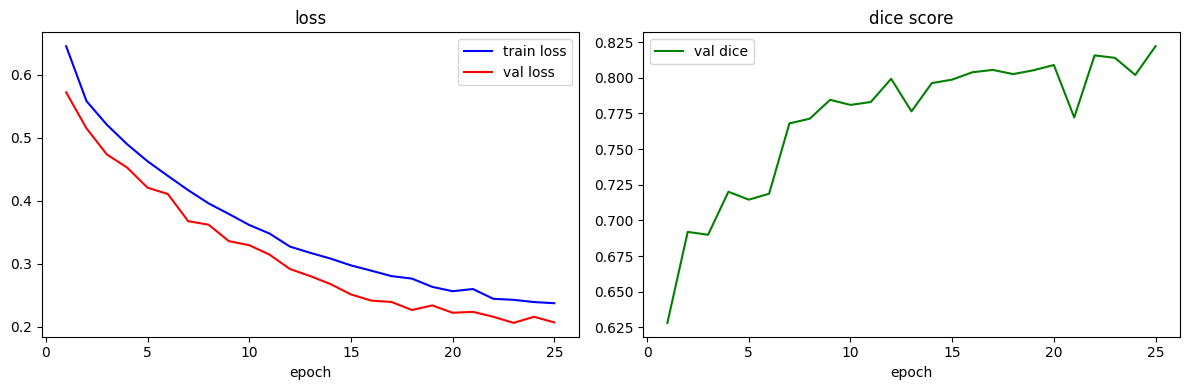

In [9]:
def plot_metrics(history):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history["train_loss"], 'b', label='train loss')
    axes[0].plot(epochs, history["val_loss"],   'r', label='val loss')
    axes[0].set_title("loss")
    axes[0].set_xlabel("epoch")
    axes[0].legend()

    axes[1].plot(epochs, history["val_dice"], 'g', label='val dice')
    axes[1].set_title("dice score")
    axes[1].set_xlabel("epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=100)
    plt.show()

plot_metrics(history)

## Testing


## Overlap-Based Pixel Metrics (Dice, IoU, Precision, Recall)


In [10]:
def compute_overlap_metrics(pred, target, threshold=0.5):
    """
    Computes Precision, Recall (Sensitivity), Intersection over Union (IoU),
    and Dice Coefficient for binary segmentations.
    """
    pred_bin = (torch.sigmoid(pred) > threshold).float()
    target_bin = (target > threshold).float()
    
    pred_flat = pred_bin.reshape(-1)
    target_flat = target_bin.reshape(-1)
    
    tp = torch.sum(pred_flat * target_flat).item()
    fp = torch.sum(pred_flat * (1.0 - target_flat)).item()
    fn = torch.sum((1.0 - pred_flat) * target_flat).item()
    tn = torch.sum((1.0 - pred_flat) * (1.0 - target_flat)).item()
    
    precision = tp / (tp + fp + 1e-7)
    recall = tp / (tp + fn + 1e-7)
    iou = tp / (tp + fp + fn + 1e-7)
    dice = (2.0 * tp) / (2.0 * tp + fp + fn + 1e-7)
    
    return {
        "precision": precision,
        "recall": recall,
        "iou": iou,
        "dice": dice
    }

## Boundary-Based Metric (HD95)


In [11]:
from scipy.spatial import KDTree

def compute_hd95(pred, target, threshold=0.5):
    """
    Computes the 95th percentile Hausdorff Distance between predicted and target boundaries.
    """
    pred_bin = (torch.sigmoid(pred) > threshold).cpu().numpy().astype(np.uint8).squeeze()
    target_bin = (target > threshold).cpu().numpy().astype(np.uint8).squeeze()
    
    pts_pred = np.argwhere(pred_bin > 0)
    pts_target = np.argwhere(target_bin > 0)
    
    if len(pts_pred) == 0 and len(pts_target) == 0:
        return 0.0
    if len(pts_pred) == 0 or len(pts_target) == 0:
        return 99.0
        
    tree_pred = KDTree(pts_pred)
    tree_target = KDTree(pts_target)
    
    d_target_to_pred, _ = tree_pred.query(pts_target)
    d_pred_to_target, _ = tree_target.query(pts_pred)
    
    hd95 = max(np.percentile(d_target_to_pred, 95), np.percentile(d_pred_to_target, 95))
    return hd95

## Batch Evaluation Loop


In [12]:
def evaluate_model_metrics(model, loader, device):
    """
    Evaluates the model over the entire dataset loader, accumulating
    all pixel-level and boundary-level metrics.
    """
    model.eval()
    
    total_metrics = {
        "precision": 0.0,
        "recall": 0.0,
        "iou": 0.0,
        "dice": 0.0,
        "hd95": 0.0
    }
    
    total_batches = len(loader)
    
    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model(imgs)
            
            if masks.shape[-2:] != preds.shape[-2:]:
                masks = TF.center_crop(masks, preds.shape[-2:])
            
            overlap = compute_overlap_metrics(preds, masks)
            total_metrics["precision"] += overlap["precision"]
            total_metrics["recall"] += overlap["recall"]
            total_metrics["iou"] += overlap["iou"]
            total_metrics["dice"] += overlap["dice"]
            
            batch_hd95 = 0.0
            for i in range(imgs.size(0)):
                batch_hd95 += compute_hd95(preds[i], masks[i])
            total_metrics["hd95"] += (batch_hd95 / imgs.size(0))
            
    for key in total_metrics:
        total_metrics[key] /= total_batches
        
    return total_metrics

## Final Results


In [13]:
print("Running test set evaluation...")
test_metrics = evaluate_model_metrics(model, test_loader, DEVICE)

print("=" * 50)
print("             TEST SET METRICS REPORT            ")
print("=" * 50)
print(f"Dice Coefficient (F1)  : {test_metrics['dice']:.4f}")
print(f"Mean IoU (Jaccard)     : {test_metrics['iou']:.4f}")
print(f"Precision (PPV)        : {test_metrics['precision']:.4f}")
print(f"Recall (Sensitivity)   : {test_metrics['recall']:.4f}")
print("-" * 50)
print(f"Hausdorff Distance 95  : {test_metrics['hd95']:.2f} pixels")
print("=" * 50)

Running test set evaluation...
             TEST SET METRICS REPORT            
Dice Coefficient (F1)  : 0.7040
Mean IoU (Jaccard)     : 0.6072
Precision (PPV)        : 0.6782
Recall (Sensitivity)   : 0.7451
--------------------------------------------------
Hausdorff Distance 95  : 28.35 pixels


## Collect Metrics Per-Image


In [14]:
def evaluate_individual_images(model, loader, device):
    """
    Evaluates the model and returns lists of scores for every individual image.
    """
    model.eval()
    
    results = {
        "Dice": [],
        "IoU": [],
        "Precision": [],
        "Recall": [],
        "HD95": []
    }
    
    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model(imgs)
            
            if masks.shape[-2:] != preds.shape[-2:]:
                masks = TF.center_crop(masks, preds.shape[-2:])
            
            for i in range(imgs.size(0)):
                overlap = compute_overlap_metrics(preds[i:i+1], masks[i:i+1])
                hd = compute_hd95(preds[i], masks[i])
                
                results["Dice"].append(overlap["dice"])
                results["IoU"].append(overlap["iou"])
                results["Precision"].append(overlap["precision"])
                results["Recall"].append(overlap["recall"])
                results["HD95"].append(hd)
                
    return results

print("Calculating individual image scores...")
per_image_scores = evaluate_individual_images(model, test_loader, DEVICE)

Calculating individual image scores...


## Performance Distribution (Violin + Box Plot)


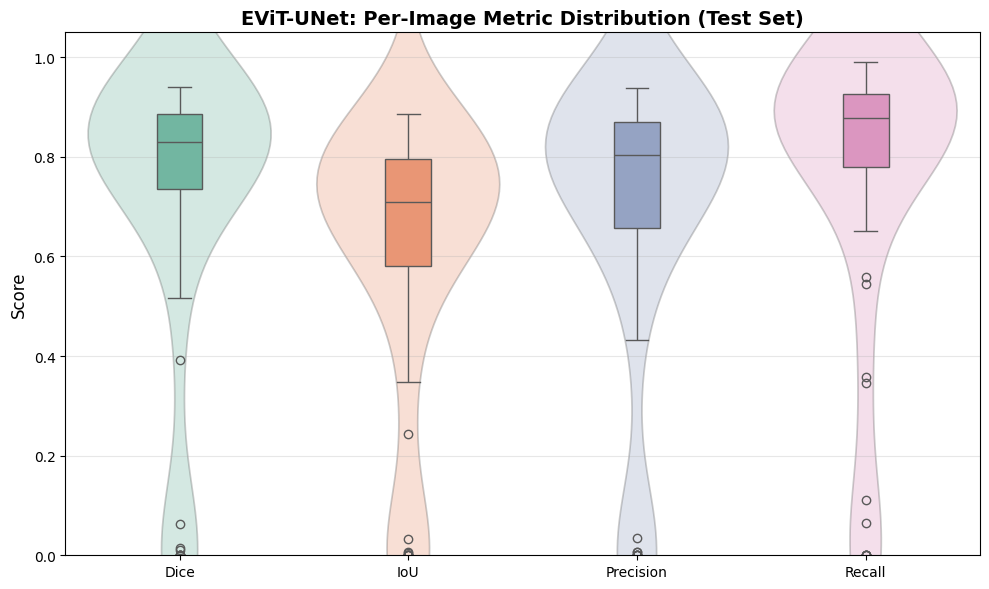

In [15]:
# Prepare data for plotting (exclude HD95 which is on a different scale)
overlap_metrics = ["Dice", "IoU", "Precision", "Recall"]
plot_data = []
for metric_name in overlap_metrics:
    for val in per_image_scores[metric_name]:
        plot_data.append({"Metric": metric_name, "Score": val})

df_plot = pd.DataFrame(plot_data)

fig, ax = plt.subplots(figsize=(10, 6))

# Violin
sns.violinplot(
    data=df_plot,
    x="Metric", y="Score",
    inner=None,
    palette="Set2",
    hue="Metric",
    legend=False,
    alpha=0.3,
    ax=ax
)

# Overlay box
sns.boxplot(
    data=df_plot,
    x="Metric", y="Score",
    width=0.2,
    palette="Set2",
    hue="Metric",
    legend=False,
    boxprops={'zorder': 2},
    ax=ax
)

ax.set_title("EViT-UNet: Per-Image Metric Distribution (Test Set)", fontsize=14, weight='bold')
ax.set_ylabel("Score", fontsize=12)
ax.set_xlabel("")
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("evit_unet_violin_box.png", dpi=150)
plt.show()


## Radar Chart


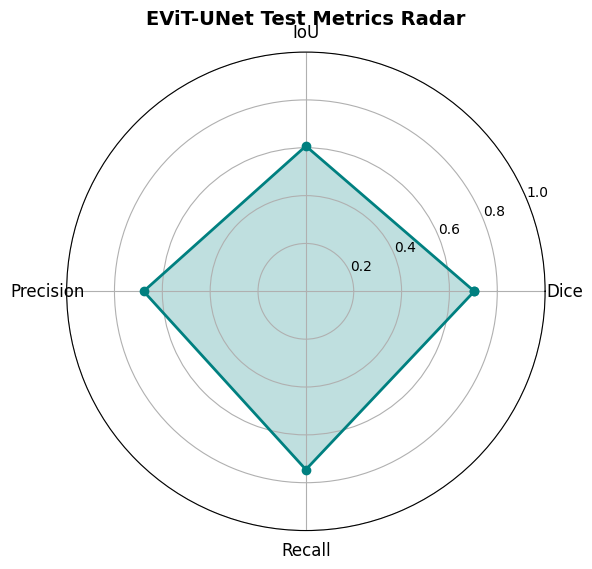

In [16]:
import numpy as np

metrics_radar = {
    "Dice":      test_metrics["dice"],
    "IoU":       test_metrics["iou"],
    "Precision": test_metrics["precision"],
    "Recall":    test_metrics["recall"],
}

labels = list(metrics_radar.keys())
values = list(metrics_radar.values())

# Close the radar
values += values[:1]
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.fill(angles, values, alpha=0.25, color='teal')
ax.plot(angles, values, 'o-', linewidth=2, color='teal')
ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=12)
ax.set_ylim(0, 1)
ax.set_title("EViT-UNet Test Metrics Radar", fontsize=14, weight='bold', pad=20)
plt.tight_layout()
plt.savefig("evit_unet_radar.png", dpi=150)
plt.show()

## Boundary Contour Overlay


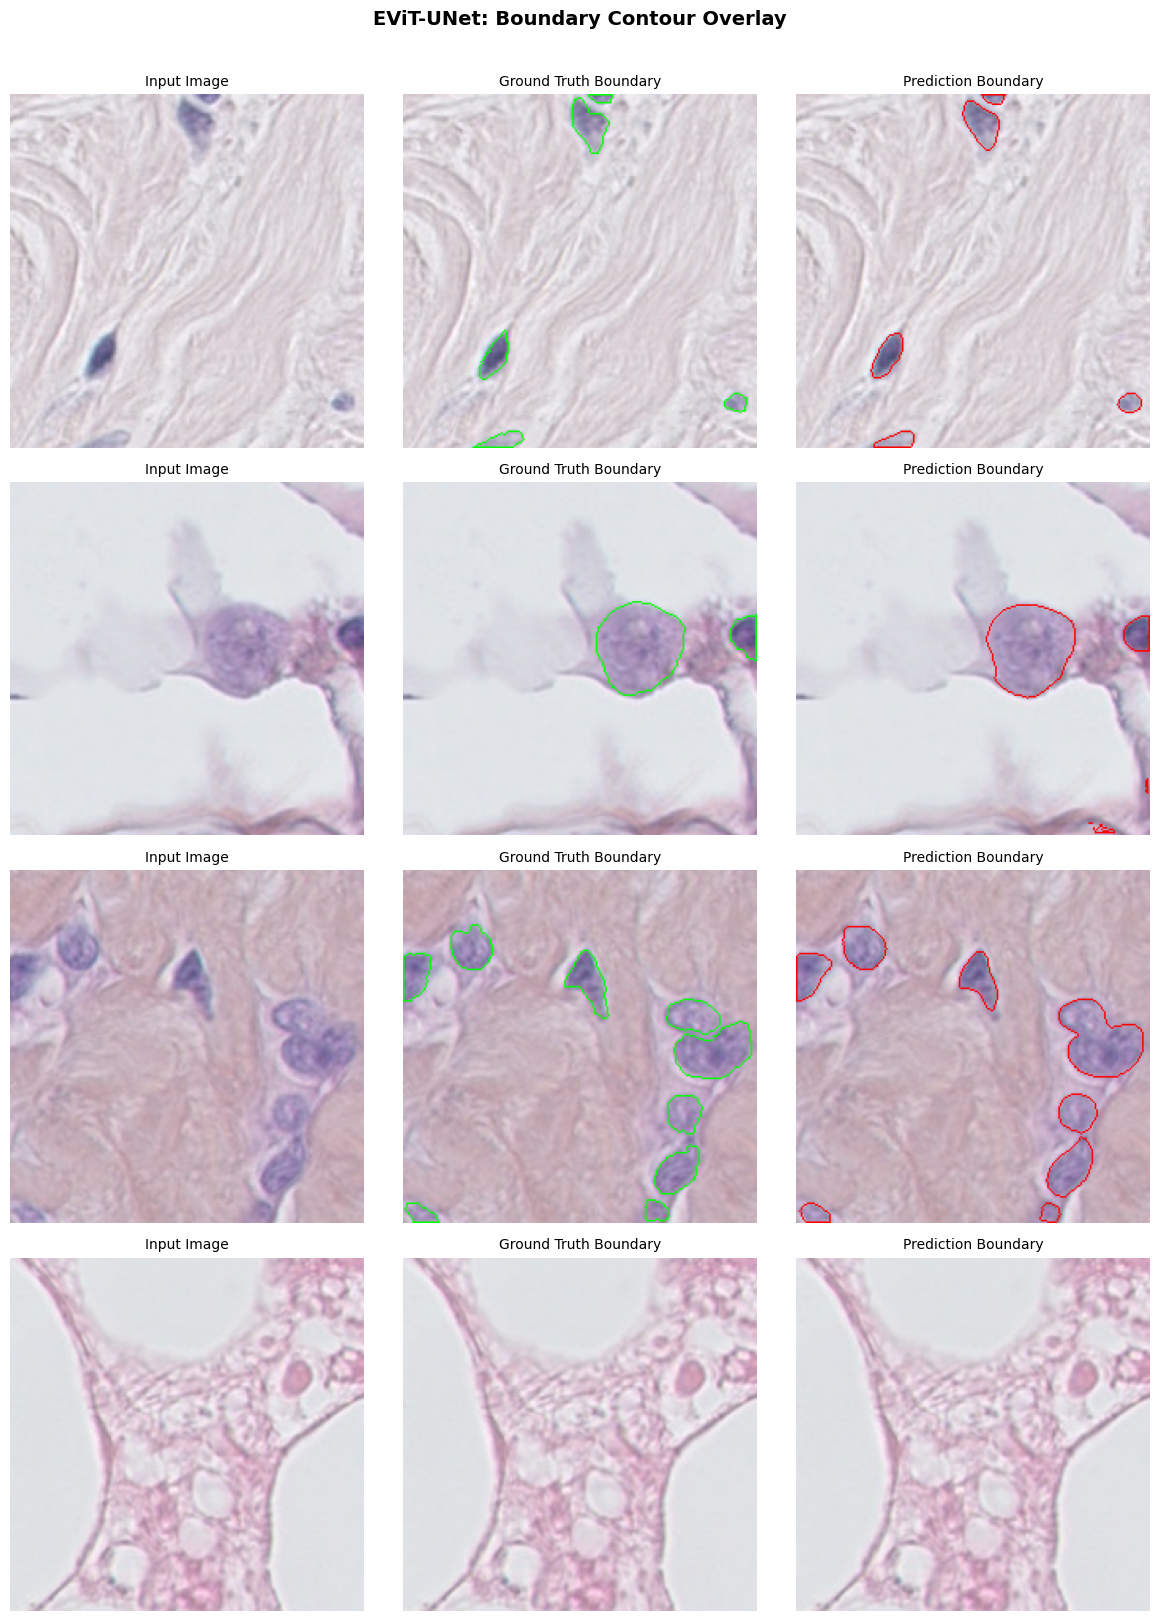

In [17]:
def plot_boundary_contours(model, loader, device, num_images=4):
    model.eval()
    fig, axes = plt.subplots(num_images, 3, figsize=(12, 4 * num_images))
    
    if num_images == 1:
        axes = axes[np.newaxis, :]
    
    with torch.no_grad():
        for idx, (imgs, masks) in enumerate(loader):
            if idx >= num_images:
                break
            imgs_dev, masks_dev = imgs.to(device), masks.to(device)
            preds = model(imgs_dev)
            
            if masks_dev.shape[-2:] != preds.shape[-2:]:
                masks_dev = TF.center_crop(masks_dev, preds.shape[-2:])
                imgs = TF.center_crop(imgs, preds.shape[-2:])
            
            img_np = imgs[0].cpu().numpy().transpose(1, 2, 0)
            mask_np = masks_dev[0, 0].cpu().numpy()
            pred_np = (torch.sigmoid(preds[0, 0]) > 0.5).cpu().numpy().astype(np.uint8)
            
            # Image
            axes[idx, 0].imshow(img_np)
            axes[idx, 0].set_title("Input Image", fontsize=10)
            axes[idx, 0].axis('off')
            
            # Ground truth contour
            gt_contours, _ = cv2.findContours(mask_np.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            img_gt = (img_np * 255).astype(np.uint8).copy()
            cv2.drawContours(img_gt, gt_contours, -1, (0, 255, 0), 1)
            axes[idx, 1].imshow(img_gt)
            axes[idx, 1].set_title("Ground Truth Boundary", fontsize=10)
            axes[idx, 1].axis('off')
            
            # Prediction contour
            pred_contours, _ = cv2.findContours(pred_np, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            img_pred = (img_np * 255).astype(np.uint8).copy()
            cv2.drawContours(img_pred, pred_contours, -1, (255, 0, 0), 1)
            axes[idx, 2].imshow(img_pred)
            axes[idx, 2].set_title("Prediction Boundary", fontsize=10)
            axes[idx, 2].axis('off')
    
    plt.suptitle("EViT-UNet: Boundary Contour Overlay", fontsize=14, weight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig("evit_unet_boundaries.png", dpi=150, bbox_inches='tight')
    plt.show()

plot_boundary_contours(model, test_loader, DEVICE, num_images=4)